In [1]:
import pandas as pd
import numpy as np
import seaborn as sns




import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
# setting Jedha color palette as default
pio.templates["jedha"] = go.layout.Template(
    layout_colorway=["#4B9AC7", "#4BE8E0", "#9DD4F3", "#97FBF6", "#2A7FAF", "#23B1AB", "#0E3449", "#015955"]
)
pio.templates.default = "jedha"
pio.renderers.default = "svg" # to be replaced by "iframe" if working on JULIE
from IPython.display import display

c:\Users\dubos\miniforge3\envs\JedhaTraining\Lib\site-packages\kaleido\_sync_server.py:11: UserWarning:




This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.




In [8]:
data = pd.read_csv('Walmart_Store_sales.csv')
data.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,6.0,18-02-2011,1572117.54,NaN,59.61,3.045,214.777523,6.858
1,13.0,25-03-2011,1807545.43,0.0,42.38,3.435,128.616064,7.470
2,17.0,27-07-2012,NaN,0.0,NaN,NaN,130.719581,5.936
3,11.0,NaN,1244390.03,0.0,84.57,NaN,214.556497,7.346
4,6.0,28-05-2010,1644470.66,0.0,78.89,2.759,212.412888,7.092


In [9]:
print(data.shape)
data.describe()

(150, 8)


,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,150.000000,1.360000e+02,138.000000,132.000000,136.000000,138.000000,135.000000
mean,9.866667,1.249536e+06,0.079710,61.398106,3.320853,179.898509,7.598430
std,6.231191,6.474630e+05,0.271831,18.378901,0.478149,40.274956,1.577173
min,1.000000,2.689290e+05,0.000000,18.790000,2.514000,126.111903,5.143000
25%,4.000000,6.050757e+05,0.000000,45.587500,2.852250,131.970831,6.597500
50%,9.000000,1.261424e+06,0.000000,62.985000,3.451000,197.908893,7.470000
75%,15.750000,1.806386e+06,0.000000,76.345000,3.706250,214.934616,8.150000
max,20.000000,2.771397e+06,1.000000,91.650000,4.193000,226.968844,14.313000


In [ ]:
data = data[data["Date"].notna()]
# data["Date"].dropna("Date")
data["Date"] = pd.to_datetime(data["Date"], dayfirst=True)
data["Year"] = data["Date"].dt.year
data["Month"] = data["Date"].dt.month
data["day"] = data["Date"].dt.day
data["day_in_week"] = data["Date"].dt.day_of_week
data.drop("Date", axis=1, inplace=True)
data.head()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,day,day_in_week
0,6.0,1572117.54,NaN,59.61,3.045,214.777523,6.858,2011,2,18,4
1,13.0,1807545.43,0.0,42.38,3.435,128.616064,7.470,2011,3,25,4
2,17.0,NaN,0.0,NaN,NaN,130.719581,5.936,2012,7,27,4
4,6.0,1644470.66,0.0,78.89,2.759,212.412888,7.092,2010,5,28,4
5,4.0,1857533.70,0.0,NaN,2.756,126.160226,7.896,2010,5,28,4


In [16]:
data = data[data["Weekly_Sales"].notna()]
data["Holiday_Flag"] = data["Holiday_Flag"].fillna(0)
data["Temperature"] = data["Temperature"].fillna(data["Temperature"].mean())

In [18]:
col_list = ["Temperature", "Fuel_Price", "CPI", "Unemployment"]

for col in col_list:
    avg = data[col].mean()
    var = data[col].std()
    data = data[data[col].between(avg-3*var, avg+3*var)]

data.describe()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,day,day_in_week
count,88.000000,8.000000e+01,78.000000,88.000000,88.000000,88.000000,88.000000,88.000000,88.000000,88.000000,88.0
mean,9.477273,1.221522e+06,0.076923,61.205341,3.294125,183.476896,7.279875,2010.909091,6.363636,15.988636,4.0
std,6.210812,6.799270e+05,0.268194,17.225448,0.491522,38.675294,0.958876,0.825406,3.078221,8.438410,0.0
min,1.000000,2.689290e+05,0.000000,18.790000,2.548000,126.139200,5.143000,2010.000000,1.000000,1.000000,4.0
25%,4.000000,5.295107e+05,0.000000,45.587500,2.812500,133.659895,6.494250,2010.000000,4.000000,9.750000,4.0
50%,8.000000,1.260826e+06,0.000000,61.450000,3.390500,201.148402,7.345500,2011.000000,6.000000,16.500000,4.0
75%,15.000000,1.817517e+06,0.000000,75.477500,3.685000,214.956372,8.090000,2012.000000,9.000000,23.000000,4.0
max,20.000000,2.771397e+06,1.000000,91.650000,4.187000,226.968844,9.342000,2012.000000,12.000000,31.000000,4.0


In [19]:
data.head()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,day,day_in_week
0,6.0,1572117.54,NaN,59.61,3.045,214.777523,6.858,2011,2,18,4
1,13.0,1807545.43,0.0,42.38,3.435,128.616064,7.470,2011,3,25,4
4,6.0,1644470.66,0.0,78.89,2.759,212.412888,7.092,2010,5,28,4
6,15.0,695396.19,0.0,69.80,4.069,134.855161,7.658,2011,6,3,4
7,20.0,2203523.20,0.0,39.93,3.617,213.023622,6.961,2012,2,3,4


Analyse monovariée

<Axes: ylabel='Weekly_Sales'>

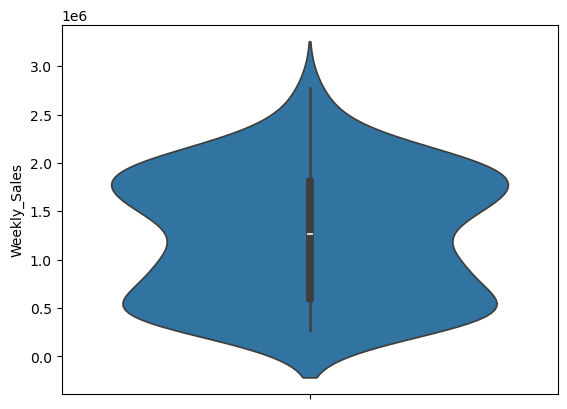

In [21]:
sns.violinplot(data=data['Weekly_Sales'])


<Axes: >

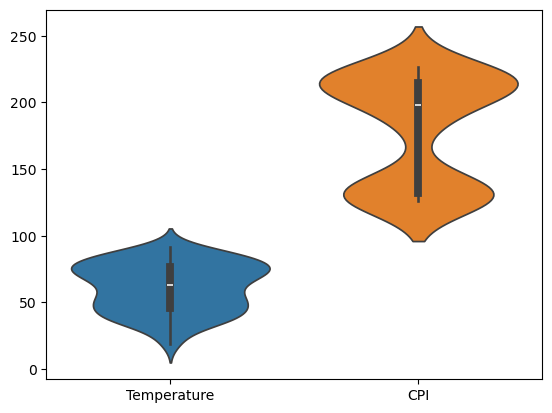

In [25]:
sns.violinplot(data=data[['Temperature', 'CPI']])

<Axes: ylabel='Fuel_Price'>

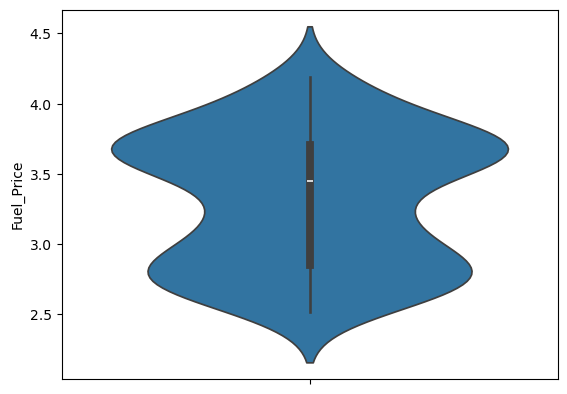

In [23]:
sns.violinplot(data=data['Fuel_Price'])

Analyse bivariée

In [29]:
data.drop(['Store', 'Date'], axis=1).corr()

,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
Weekly_Sales,1.000000,0.037037,-0.165991,-0.019087,-0.287227,0.055191
Holiday_Flag,0.037037,1.000000,-0.187922,-0.117447,0.171969,0.096934
Temperature,-0.165991,-0.187922,1.000000,0.048943,0.137936,-0.030122
Fuel_Price,-0.019087,-0.117447,0.048943,1.000000,-0.159881,0.086241
CPI,-0.287227,0.171969,0.137936,-0.159881,1.000000,-0.348072
Unemployment,0.055191,0.096934,-0.030122,0.086241,-0.348072,1.000000


Forte corrélation négative entre: CPI et Unemployment (-0.34), CPI et Weekly_Sales (-0.28)

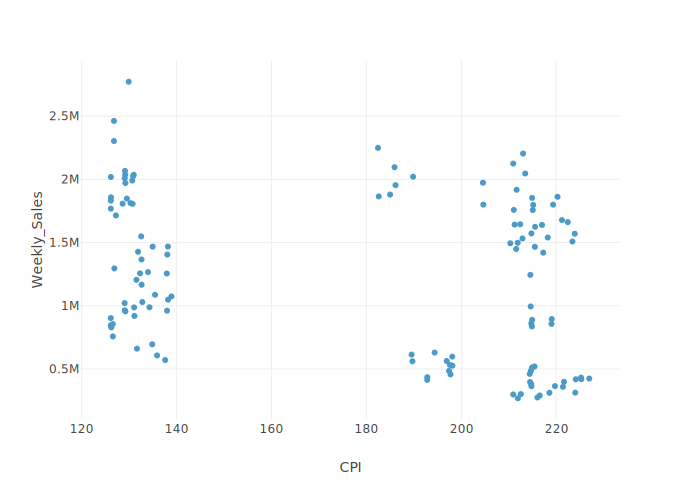

In [31]:
px.scatter(data, x='CPI', y='Weekly_Sales')

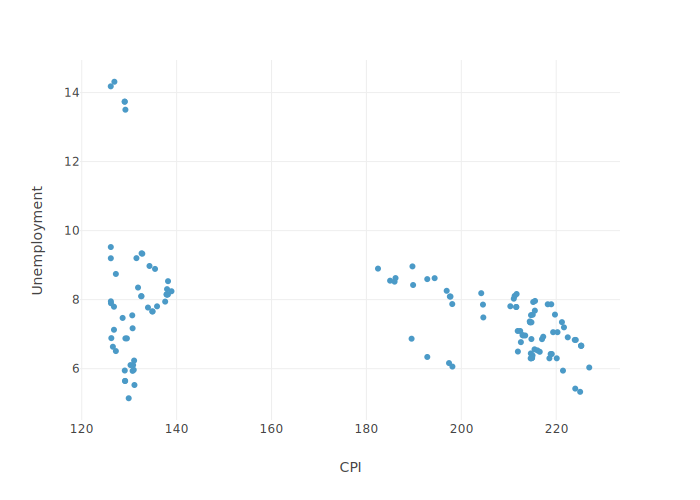

In [32]:
px.scatter(data, x='CPI', y='Unemployment')

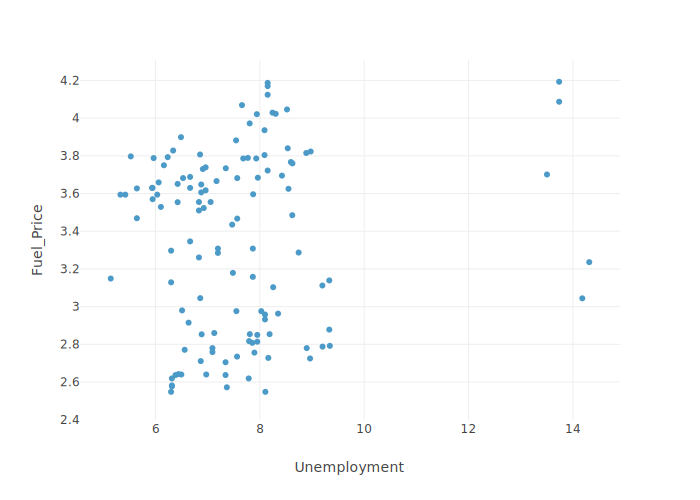

In [38]:
px.scatter(data, x='Unemployment', y='Fuel_Price')

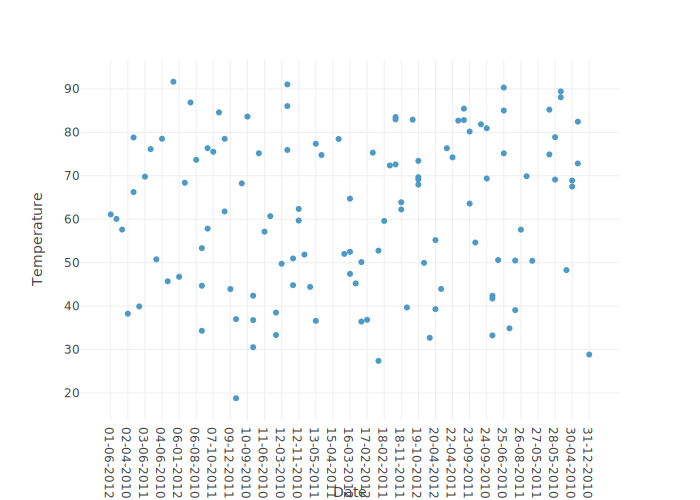

In [40]:
data.sort_values('Date', inplace=True)
px.scatter(data, x='Date', y='Temperature')